In [ ]:
#-----------------------------------------
# Step 1: Imports & Dependencies Setup
#-----------------------------------------

In [ ]:
# !pip install yfinance

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#-----------------------------------------
# Step 2: Download Stock Data & Data Preprocessing
#-----------------------------------------

In [ ]:
# 1. Download Apple Stock Data (AAPL)
ticker = "AAPL"
df = yf.download(ticker, start="2015-01-01", end="2024-01-01")

# Extract the 'Close' prices (Single feature time series)
prices = df['Close'].values.reshape(-1, 1)

# 2. Scale features between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

# 3. Create Sequences (Sliding Window Approach)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Look back 60 trading days
X, y = create_sequences(prices_scaled, seq_length)

# 4. Train / Test Split (Time Series split: Chronological order without shuffling)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. PyTorch Custom Dataset
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False) # shuffle=False is critical for time series!
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

/tmp/ipykernel_1891/1595640489.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
#-----------------------------------------
# Step 3: Define LSTM Deep Learning Architecture
#-----------------------------------------

In [ ]:
class StockLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=1):
        super(StockLSTM, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 # Dropout between LSTM layers to prevent overfitting
        )

        # Fully Connected Output Layer
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Instantiate model
model = StockLSTM(input_dim=1, hidden_dim=64, num_layers=2, output_dim=1).to(device)
print(model)

StockLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
#-----------------------------------------
# Step 4: Loss Function, Optimizer & Scheduler Setup
#-----------------------------------------

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Scheduler to reduce learning rate when test loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [ ]:
#-----------------------------------------
# Step 5: Training and Evaluation Loop
#-----------------------------------------

In [ ]:
epochs = 40
train_losses = []
test_losses = []

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    running_train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- EVALUATION ---
    model.eval()
    running_test_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item() * inputs.size(0)

    epoch_test_loss = running_test_loss / len(test_dataset)
    test_losses.append(epoch_test_loss)

    # Step scheduler
    scheduler.step(epoch_test_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f}")

Epoch [1/40] | Train Loss: 0.000483 | Test Loss: 0.001241
Epoch [10/40] | Train Loss: 0.000648 | Test Loss: 0.000748
Epoch [20/40] | Train Loss: 0.000388 | Test Loss: 0.001464
Epoch [30/40] | Train Loss: 0.000655 | Test Loss: 0.001152
Epoch [40/40] | Train Loss: 0.000424 | Test Loss: 0.000636


In [ ]:
#-----------------------------------------
# Step 6: Plot Loss Curves & Evaluate Real Dollar Predictions
#-----------------------------------------

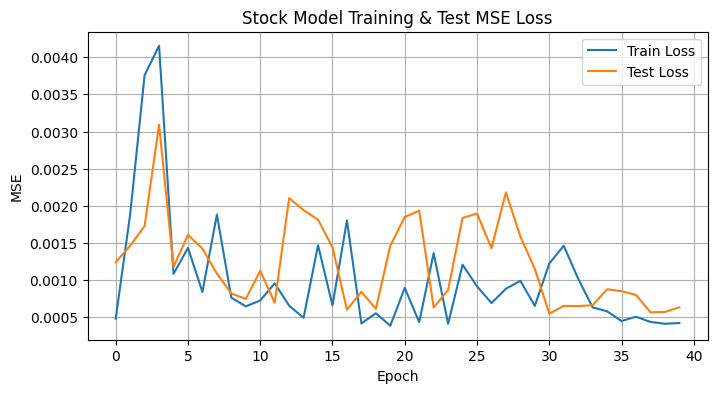


--- Stock Market Price Prediction Evaluation ---
Mean Absolute Error (MAE): $3.68
Root Mean Squared Error (RMSE): $4.42
R² Score: 0.9438


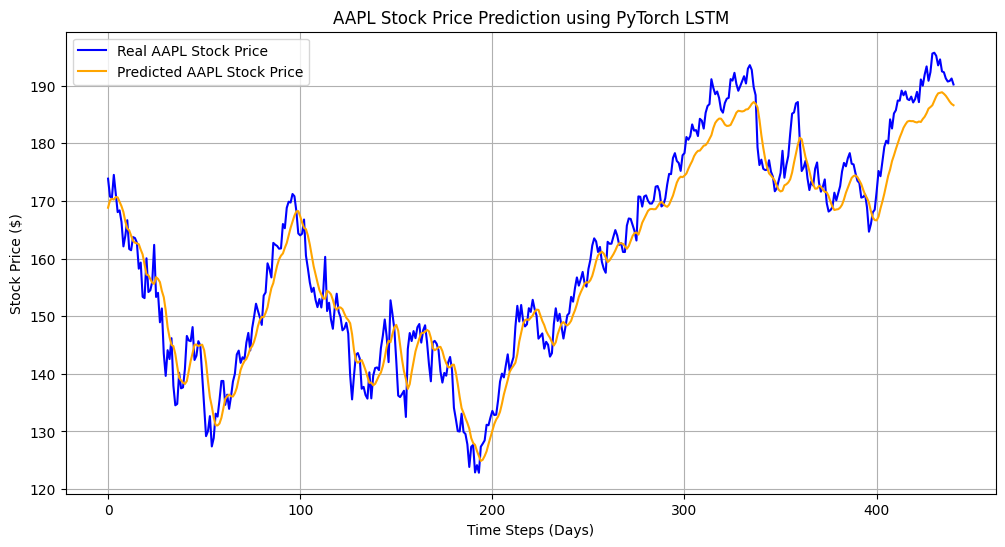

In [ ]:
# 1. Plot Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Stock Model Training & Test MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

# 2. Get Test Predictions
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    scaled_predictions = model(X_test_tensor).cpu().numpy()

# Reverse scaling back to original dollar amounts
real_predictions = scaler.inverse_transform(scaled_predictions)
real_y_test = scaler.inverse_transform(y_test)

# 3. Calculate Performance Metrics
mae = mean_absolute_error(real_y_test, real_predictions)
rmse = np.sqrt(mean_squared_error(real_y_test, real_predictions))
r2 = r2_score(real_y_test, real_predictions)

print("\n--- Stock Market Price Prediction Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# 4. Plot Real vs Predicted Stock Prices
plt.figure(figsize=(12, 6))
plt.plot(real_y_test, label='Real AAPL Stock Price', color='blue')
plt.plot(real_predictions, label='Predicted AAPL Stock Price', color='orange')
plt.title('AAPL Stock Price Prediction using PyTorch LSTM')
plt.xlabel('Time Steps (Days)')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#-----------------------------------------
# Step 7: Predicting Future Stock Prices (Next Day Prediction)
#-----------------------------------------

In [ ]:
model.eval()

# Extract the last 60 days from the dataset
last_60_days = prices_scaled[-seq_length:]
last_60_days_tensor = torch.tensor(last_60_days, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    next_day_scaled_pred = model(last_60_days_tensor).cpu().numpy()

next_day_price = scaler.inverse_transform(next_day_scaled_pred)[0][0]
last_known_price = prices[-1][0]

print(f"\nLast Known Stock Price: ${last_known_price:.2f}")
print(f"Predicted Next Day Stock Price: ${next_day_price:.2f}")


Last Known Stock Price: $190.21
Predicted Next Day Stock Price: $186.32


In [ ]:

x = [1, 2, 3, 4, 5]
print(x[:3])

[1, 2, 3]


/tmp/ipykernel_2700/2625411252.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Epoch [1/40] | Train Loss: 0.008197 | Test Loss: 0.010492
Epoch [10/40] | Train Loss: 0.000690 | Test Loss: 0.000944
Epoch [20/40] | Train Loss: 0.000438 | Test Loss: 0.000546
Epoch [30/40] | Train Loss: 0.000276 | Test Loss: 0.000608
Epoch [40/40] | Train Loss: 0.000247 | Test Loss: 0.000625


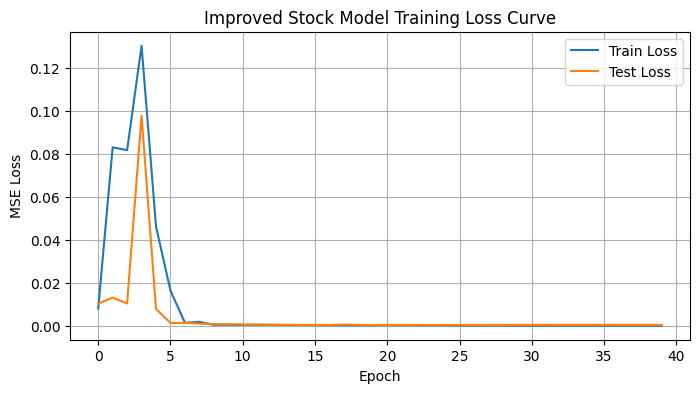


--- Improved Stock Model Evaluation ---
Mean Absolute Error (MAE): $3.47
Root Mean Squared Error (RMSE): $4.38
R² Score: 0.9449


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Step 1: Download Data & Technical Feature Engineering ---
ticker = 'AAPL'
df = yf.download(ticker, start='2015-01-01', end='2024-01-01', auto_adjust=True)

# 1. Feature Engineering
df['Returns'] = df['Close'].pct_change()
df['High_Low_Pct'] = (df['High'] - df['Low']) / df['Close']
df['Volatility'] = df['Returns'].rolling(window=10).std()

# Calculate RSI (14 days)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Drop NaN values created by indicators
df.dropna(inplace=True)

# Define Multi-Feature Array (Close price + Indicators)
feature_cols = ['Close', 'Volume', 'Returns', 'High_Low_Pct', 'RSI']
features_data = df[feature_cols].values
target_data = df[['Close']].values

# --- Step 2: Scaling & Sliding Window ---
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_x.fit_transform(features_data)
scaled_target = scaler_y.fit_transform(target_data)

def create_multivariate_sequences(X_data, y_data, sequence_length=60):
    X, y = [], []
    for i in range(len(X_data) - sequence_length):
        X.append(X_data[i : i + sequence_length])
        y.append(y_data[i + sequence_length])
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 60
X, y = create_multivariate_sequences(scaled_features, scaled_target, SEQUENCE_LENGTH)

# Chronological Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Step 3: Improved GRU Architecture ---
class StockGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):
        super(StockGRU, self).__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # GRU returns (out, h_n)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

input_dim = len(feature_cols)
model = StockGRU(input_dim=input_dim, hidden_dim=64, num_layers=2).to(device)

# --- Step 4: Loss, Optimizer & Gradient Clipping ---
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

epochs = 40
train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        # Gradient Clipping to smooth loss curve
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item() * inputs.size(0)

    epoch_test_loss = running_test_loss / len(test_dataset)
    test_losses.append(epoch_test_loss)

    scheduler.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f}")

# --- Step 5: Evaluation & Plotting ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Improved Stock Model Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    scaled_preds = model(X_test_tensor).cpu().numpy()

real_preds = scaler_y.inverse_transform(scaled_preds)
real_targets = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(real_targets, real_preds)
rmse = np.sqrt(mean_squared_error(real_targets, real_preds))
r2 = r2_score(real_targets, real_preds)

print("\n--- Improved Stock Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")

In [3]:
model.eval()

# Extract last 60 days of scaled features
last_60_features = scaled_features[-60:]
input_tensor = torch.tensor(last_60_features, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    next_day_scaled = model(input_tensor).cpu().numpy()

# Inverse transform prediction and last known price
next_day_price = scaler_y.inverse_transform(next_day_scaled)[0][0]

# Convert the Series element to a scalar float
last_real_price = float(df['Close'].iloc[-1].item())

print(f"Last Actual Close Price: ${last_real_price:.2f}")
print(f"Model Predicted Next Day Price: ${next_day_price:.2f}")

Last Actual Close Price: $190.21
Model Predicted Next Day Price: $187.29
